## 이상치 탐지(IQR/Z-score)와 통계적 유의성 검정

- IQR(사분위범위) 방식과 Z-score 방식, 두 가지로 이상치를 탐지하고 결과를 비교
- scipy의 t-rjawjddmfh "두 카테고리의 평균 가격 차이가 통계적으로 유의미한가?"를 직접 검증

In [2]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl



load_dotenv()

USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")
mpl.rc('font', family='AppleGothic')
mpl.rc('axes', unicode_minus=False)

In [3]:
with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)
# with 블록을 벗어나는 순간 자동으로 연결이 닫힘
df.head()

/var/folders/4j/qgl7j0hx7y33d7l5bjgf9h9h0000gn/T/ipykernel_51985/1447268984.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE
0,1,떡볶이,분식,9000,4.5,강남구,2026-08-01
1,2,치킨,치킨,22000,4.8,서초구,2026-08-02
2,3,피자,피자,25000,4.2,강남구,2026-08-03
3,4,짜장면,중식,8000,4.0,송파구,2026-08-04
4,5,마라탕,중식,13000,4.6,강남구,2026-08-05


In [4]:
import numpy as np

Q1 = df["PRICE"].quantile(0.25) # 아래에서 25% 지점에 있는 값
Q3 = df["PRICE"].quantile(0.75)
IQR = Q3-Q1 # 50% 가 몰려 있는 값
# 하한선
lower_bound = Q1 - 1.5 * IQR # 50%의 1.5배만큼을 Q1아래로 여유로 두고 그 바깥을 '너무 튄 값'으로 간주
# 상한선
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df[(df["PRICE"] < lower_bound) | (df["PRICE"] > upper_bound)]
print(f"IQR 범위: {lower_bound:.0f} ~ {upper_bound:.0f}")
print(f"IQR 기준 이상치: {len(iqr_outliers)}건")
print(iqr_outliers[["MENU_NAME", "PRICE"]])



IQR 범위: -12000 ~ 44000
IQR 기준 이상치: 0건
Empty DataFrame
Columns: [MENU_NAME, PRICE]
Index: []


In [ ]:
mean_price = df["PRICE"].mean()
std_price = df["PRICE"].std()
# Z_SCORE: 이 값이 평균에서 표준편차 몇배만큼 떨어져 있는가를 분석한 컬럼
# 0이면 정확히 평균과 같음
df["Z_SCORE"] = (df["PRICE"] - mean_price)/std_price

z_outliers = df[df["Z_SCORE"].abs()>2] # 평균에서 표준편차의 2배이상 떨어져 있으면 이상치 값으로 판단
print(f"Z-score 기준 (|z|>2)이상치 {len(z_outliers)}건")
print(z_outliers[["MENU_NAME","PRICE","Z_SCORE"]])

Z-score 기준 (|z|>2)이상치 0건
Empty DataFrame
Columns: [MENU_NAME, PRICE, Z_SCORE]
Index: []


In [6]:
from scipy import stats
# t-검정: 두 카테고리 평균 가격 차이가 의미 있는지를 검증
group_a = df[df["CATEGORY"] == "치킨"]["PRICE"]
group_b = df[df["CATEGORY"] == "중식"]["PRICE"]

# stats.ttest_ind : 서로 다른 집단을 독립적으로 비교할 때 사용함 (independent)
# equl_var=False: 두 그룹의 분산(흩어진 정도)가 같다고 가정하지 않겠다(즉, 치킨과 짜장면의 가격 변동폭이 다름)
t_stat, p_value = stats.ttest_ind(group_a,group_b,equal_var=False)

print(f"치킨 평균가격: {group_a.mean():.0f}원 (n={len(group_a)})")
print(f"중식 평균가격: {group_b.mean():.0f}원 (n={len(group_b)})")
print(f"\nt-통계량: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")
 
if p_value <0.05:
    print("→ 통계적으로 유의미한 차이가 있다고 볼 수 있음 (p < 0.05)")
else:
    print("→ 통계적으로 유의미한 차이라고 보기 어려움 (p >= 0.05)")

치킨 평균가격: 22250원 (n=6)
중식 평균가격: 11800원 (n=10)

t-통계량: 7.666
p-value: 0.0000
→ 통계적으로 유의미한 차이가 있다고 볼 수 있음 (p < 0.05)


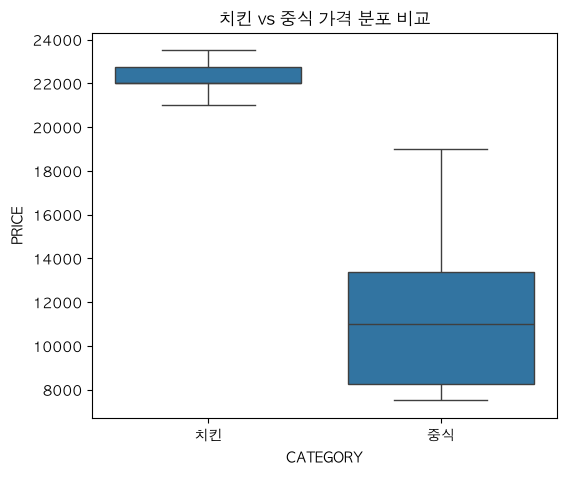

In [7]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.boxplot(data=df[df["CATEGORY"].isin(["치킨", "중식"])], x="CATEGORY", y="PRICE")
plt.title("치킨 vs 중식 가격 분포 비교")
plt.show()